# 003 Imbalance Analysis

Цель: анализ L1 и L10 imbalance, корреляция с движением mid price.
imbalance = (bid_volume - ask_volume) / (bid_volume + ask_volume)

In [3]:
# Добавляет корень проекта в path
import sys
from pathlib import Path

import pandas as pd

root = None
for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (p / "pyproject.toml").exists() and (p / "research").is_dir():
        sys.path.insert(0, str(p))
        root = p
        break

root = root or Path.cwd()
data_dir = root / "data" / "reconstructed"

In [4]:
# Путь к Parquet (подставь свой файл)
# data_dir из первой ячейки (root / data / reconstructed) — выполни её

# Путь к одному часовому parquet
parquet_path = data_dir / "BTC-USDT-SWAP" / "grid100ms" / "2026-03-04" / (
    "book_grid100ms_BTC-USDT-SWAP_2026-03-04_10-00-00__2026-03-04_11-00-00.parquet"
)
if not parquet_path.exists():
    found = sorted(data_dir.rglob("*.parquet"))
    parquet_path = found[0] if found else parquet_path
    if found:
        print("Файл по умолчанию не найден, загружаю:", parquet_path)

df = pd.read_parquet(parquet_path)
df

,ts_event,inst_id,anchor_snapshot_ts,reconstruction_mode,mid_px,spread_px,bid_px_01,bid_sz_01,bid_px_02,bid_sz_02,...,ask_px_06,ask_sz_06,ask_px_07,ask_sz_07,ask_px_08,ask_sz_08,ask_px_09,ask_sz_09,ask_px_10,ask_sz_10
0,2026-03-04 10:00:00+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,383.46,71492.3,0.01,...,71494.9,0.03,71495.0,0.01,71496.0,0.07,71496.3,0.03,71496.9,0.02
1,2026-03-04 10:00:00.100000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,383.46,71492.3,0.71,...,71494.9,0.03,71495.0,0.01,71496.0,0.07,71496.3,0.03,71496.4,0.70
2,2026-03-04 10:00:00.200000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,333.47,71492.3,0.01,...,71494.9,0.73,71495.0,0.01,71495.3,0.70,71496.0,0.78,71496.2,0.70
3,2026-03-04 10:00:00.300000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,337.18,71492.3,0.01,...,71494.9,0.03,71495.0,0.01,71495.5,0.70,71496.0,0.08,71496.3,0.03
4,2026-03-04 10:00:00.400000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,353.48,71492.3,0.01,...,71495.0,0.01,71496.0,0.02,71496.9,0.02,71497.0,8.73,71497.3,0.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35996,2026-03-04 10:59:59.600000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71305.35,0.1,71305.3,160.55,71305.2,0.01,...,71306.3,0.71,71306.4,0.01,71306.5,0.71,71306.6,0.71,71306.7,0.03
35997,2026-03-04 10:59:59.700000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71305.35,0.1,71305.3,159.89,71305.2,0.01,...,71306.3,0.71,71306.4,0.01,71306.5,0.71,71306.6,0.71,71306.7,0.03
35998,2026-03-04 10:59:59.800000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71305.35,0.1,71305.3,159.89,71305.2,0.01,...,71306.8,0.02,71306.9,80.76,71307.0,60.01,71307.1,60.00,71307.2,60.00
35999,2026-03-04 10:59:59.900000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71305.35,0.1,71305.3,159.80,71305.2,0.01,...,71306.8,0.02,71306.9,80.76,71307.0,60.01,71307.1,60.00,71307.2,60.00


In [5]:
import numpy as np

# STEP 1 — sort & take 1 hour slice
_df = df.copy()
_df["ts_event"] = pd.to_datetime(_df["ts_event"], utc=True)
_df = _df.sort_values("ts_event").reset_index(drop=True)

start_ts = _df["ts_event"].min()
end_ts = start_ts + pd.Timedelta(hours=1)
_df = _df[_df["ts_event"].between(start_ts, end_ts)].reset_index(drop=True)

print("Loaded rows:", len(_df))
print("Time range:", _df["ts_event"].min(), "..", _df["ts_event"].max())

Loaded rows: 36001
Time range: 2026-03-04 10:00:00+00:00 .. 2026-03-04 11:00:00+00:00


In [6]:
# STEP 2 — mid price
_df["mid_price"] = (_df["bid_px_01"] + _df["ask_px_01"]) / 2

# STEP 3 — imbalance
# A) L1
_denom_l1 = (_df["bid_sz_01"] + _df["ask_sz_01"]).replace(0, np.nan)
_df["imbalance_l1"] = ((_df["bid_sz_01"] - _df["ask_sz_01"]) / _denom_l1).fillna(0)

# B) L5
bid5_cols = [f"bid_sz_{i:02d}" for i in range(1, 6)]
ask5_cols = [f"ask_sz_{i:02d}" for i in range(1, 6)]
_df["sum_bid_5"] = _df[bid5_cols].sum(axis=1)
_df["sum_ask_5"] = _df[ask5_cols].sum(axis=1)
_denom_l5 = (_df["sum_bid_5"] + _df["sum_ask_5"]).replace(0, np.nan)
_df["imbalance_l5"] = ((_df["sum_bid_5"] - _df["sum_ask_5"]) / _denom_l5).fillna(0)

_df[["ts_event", "mid_price", "imbalance_l1", "imbalance_l5"]].head()

,ts_event,mid_price,imbalance_l1,imbalance_l5
0,2026-03-04 10:00:00+00:00,71492.45,0.510785,0.576384
1,2026-03-04 10:00:00.100000+00:00,71492.45,0.510785,0.577382
2,2026-03-04 10:00:00.200000+00:00,71492.45,0.212662,0.312280
3,2026-03-04 10:00:00.300000+00:00,71492.45,0.219480,0.319160
4,2026-03-04 10:00:00.400000+00:00,71492.45,0.954116,0.951331


In [7]:
# STEP 4 — future movement target, horizon=200ms => +2 rows for 100ms grid
_df["future_mid"] = _df["mid_price"].shift(-2)
_df["delta"] = _df["future_mid"] - _df["mid_price"]

_df["target"] = np.sign(_df["delta"]).astype("Int64")

# drop tail rows where future_mid is NaN
_df2 = _df.dropna(subset=["future_mid"]).reset_index(drop=True)
print("Rows after horizon shift:", len(_df2))
_df2[["ts_event", "mid_price", "future_mid", "delta", "target"]].head()

Rows after horizon shift: 35999


,ts_event,mid_price,future_mid,delta,target
0,2026-03-04 10:00:00+00:00,71492.45,71492.45,0.0,0
1,2026-03-04 10:00:00.100000+00:00,71492.45,71492.45,0.0,0
2,2026-03-04 10:00:00.200000+00:00,71492.45,71492.45,0.0,0
3,2026-03-04 10:00:00.300000+00:00,71492.45,71496.95,4.5,1
4,2026-03-04 10:00:00.400000+00:00,71492.45,71499.95,7.5,1



imbalance_l1
mean: 0.04251063440503535
std: 0.6332791814043708
min: -0.9999886573732745 | max: 0.9999837500101563
% positive: 54.44317897719381
% negative: 45.55682102280619

imbalance_l5
mean: 0.041829408986606094
std: 0.6387202915908202
min: -0.9999443798632858 | max: 0.9999460654765115
% positive: 53.9792772021445
% negative: 46.0207227978555


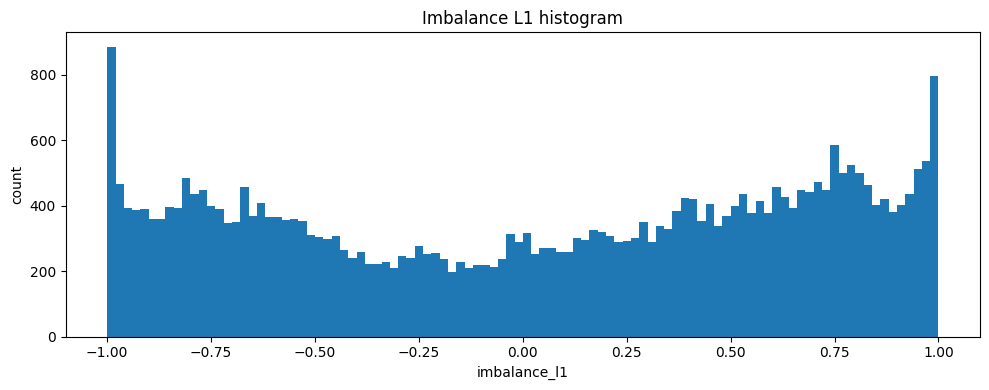

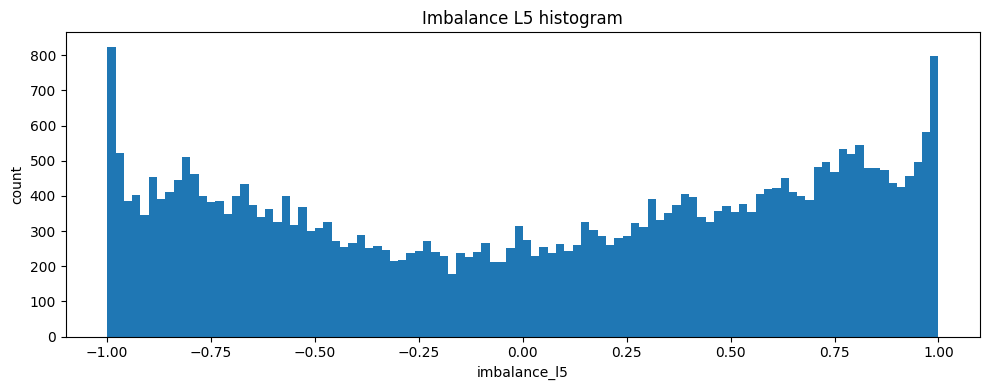

In [8]:
import matplotlib.pyplot as plt

# STEP 5 — basic statistics

def stats_series(s: pd.Series, name: str) -> None:
    s = s.dropna()
    print(f"\n{name}")
    print("mean:", s.mean())
    print("std:", s.std())
    print("min:", s.min(), "| max:", s.max())
    print("% positive:", (s > 0).mean() * 100)
    print("% negative:", (s < 0).mean() * 100)

stats_series(_df2["imbalance_l1"], "imbalance_l1")
stats_series(_df2["imbalance_l5"], "imbalance_l5")

# STEP 6 — distribution plots (histograms)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(_df2["imbalance_l1"].values, bins=100)
ax.set_title("Imbalance L1 histogram")
ax.set_xlabel("imbalance_l1")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(_df2["imbalance_l5"].values, bins=100)
ax.set_title("Imbalance L5 histogram")
ax.set_xlabel("imbalance_l5")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

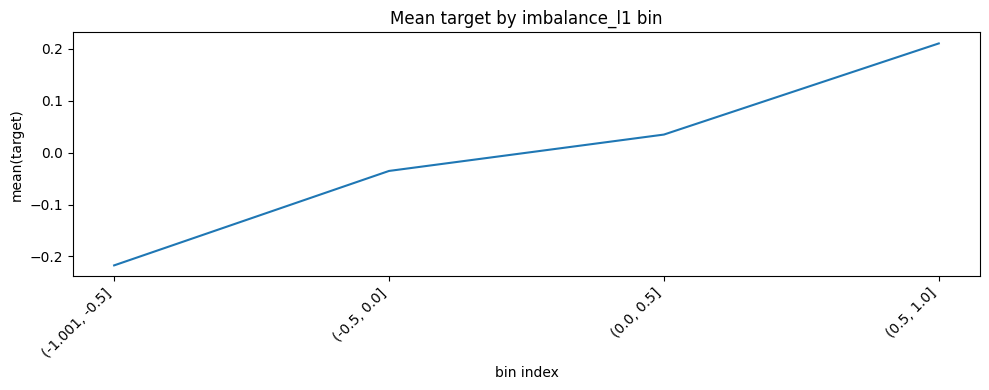

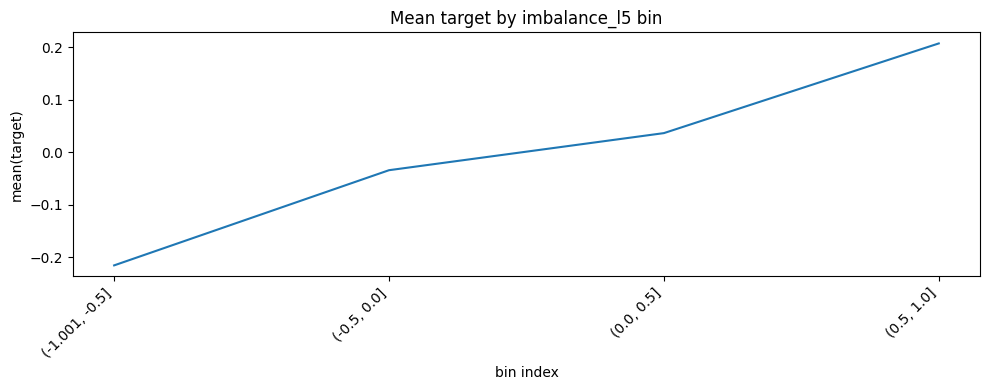

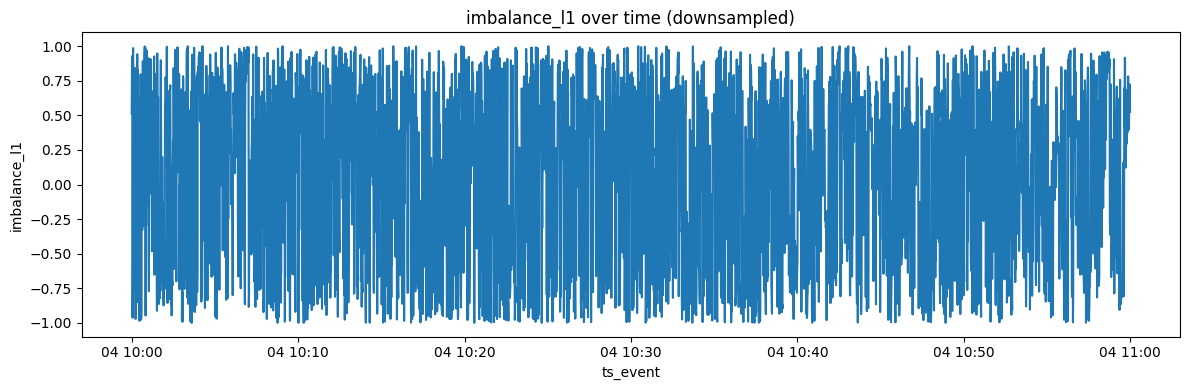

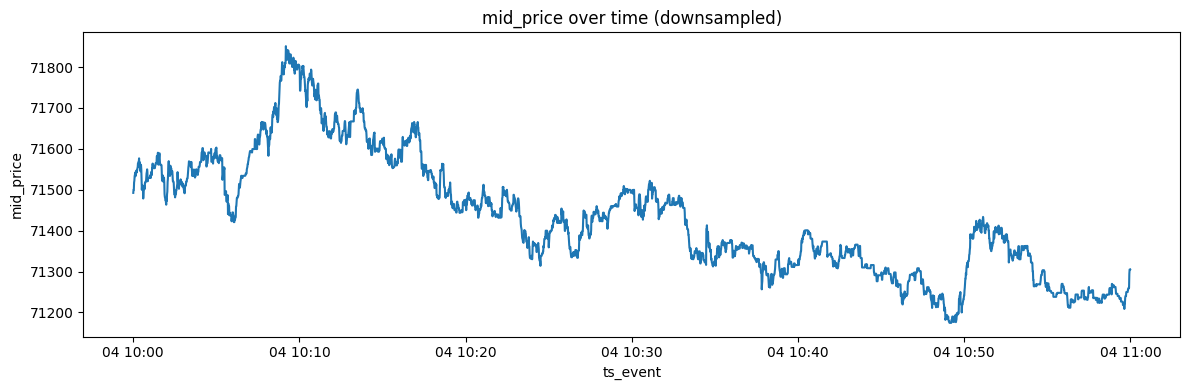

Correlation imbalance_l1 vs delta: 0.2694890264340715
Correlation imbalance_l5 vs delta: 0.26934729611414937

Extreme events abs(imbalance_l1) > 0.8
count: 9355
avg delta: -0.00256012827374503
mean target: 0.007910208444681988


In [9]:
# STEP 7 — relationship with future price direction via bins
bins = [-1.0, -0.5, 0.0, 0.5, 1.0]

_df2["bin_l1"] = pd.cut(_df2["imbalance_l1"], bins=bins, include_lowest=True)
_df2["bin_l5"] = pd.cut(_df2["imbalance_l5"], bins=bins, include_lowest=True)

mean_target_l1 = _df2.groupby("bin_l1", observed=True)["target"].mean()
mean_target_l5 = _df2.groupby("bin_l5", observed=True)["target"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(mean_target_l1)), mean_target_l1.values)
ax.set_title("Mean target by imbalance_l1 bin")
ax.set_xlabel("bin index")
ax.set_ylabel("mean(target)")
ax.set_xticks(range(len(mean_target_l1)))
ax.set_xticklabels([str(x) for x in mean_target_l1.index], rotation=45, ha="right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(mean_target_l5)), mean_target_l5.values)
ax.set_title("Mean target by imbalance_l5 bin")
ax.set_xlabel("bin index")
ax.set_ylabel("mean(target)")
ax.set_xticks(range(len(mean_target_l5)))
ax.set_xticklabels([str(x) for x in mean_target_l5.index], rotation=45, ha="right")
plt.tight_layout()
plt.show()

# STEP 8 — time series (downsample)
down = _df2.iloc[::10].copy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(down["ts_event"], down["imbalance_l1"].values)
ax.set_title("imbalance_l1 over time (downsampled)")
ax.set_xlabel("ts_event")
ax.set_ylabel("imbalance_l1")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(down["ts_event"], down["mid_price"].values)
ax.set_title("mid_price over time (downsampled)")
ax.set_xlabel("ts_event")
ax.set_ylabel("mid_price")
plt.tight_layout()
plt.show()

# STEP 9 — correlation
corr_l1 = _df2["imbalance_l1"].corr(_df2["delta"])
corr_l5 = _df2["imbalance_l5"].corr(_df2["delta"])
print("Correlation imbalance_l1 vs delta:", corr_l1)
print("Correlation imbalance_l5 vs delta:", corr_l5)

# STEP 10 — extreme events
extreme = _df2[_df2["imbalance_l1"].abs() > 0.8]
print("\nExtreme events abs(imbalance_l1) > 0.8")
print("count:", len(extreme))
print("avg delta:", extreme["delta"].mean())
print("mean target:", extreme["target"].mean())